**Environment Setup & Data Acquisition**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load public dataset (Titanic as standard benchmark)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Display initial inspection
print("Initial Shape:", df.shape)
df.info()
df.head()

Initial Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Data Cleaning & Preprocessing**

In [9]:
# 1. Remove duplicates
df = df.drop_duplicates()

# 2. Check missing values
missing_before = df.isnull().sum()
print("Missing Values Before:\n", missing_before[missing_before > 0])

# 3. Handle missing values with domain logic
# Fill missing 'Age' with median age per Pclass
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Fill missing 'Embarked' with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop 'Cabin' due to excessive missingness (>75%)
df = df.drop(columns=['Cabin'])

# 4. Correct Data Types
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

print("\nMissing Values After:\n", df.isnull().sum().sum())

Missing Values Before:
 Age         177
Cabin       687
Embarked      2
dtype: int64

Missing Values After:
 0


**Exploratory Data Analysis & Visualizations**

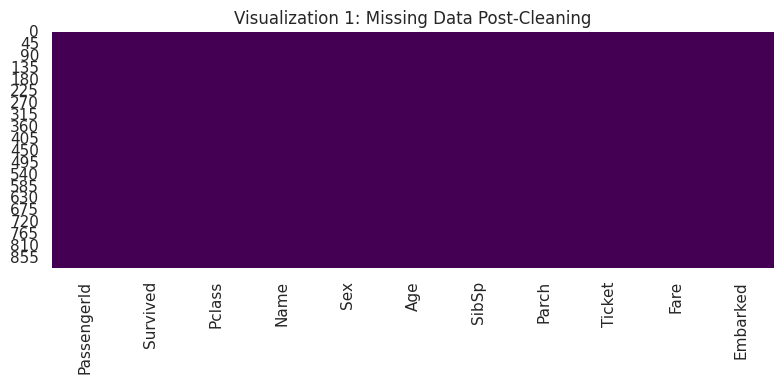

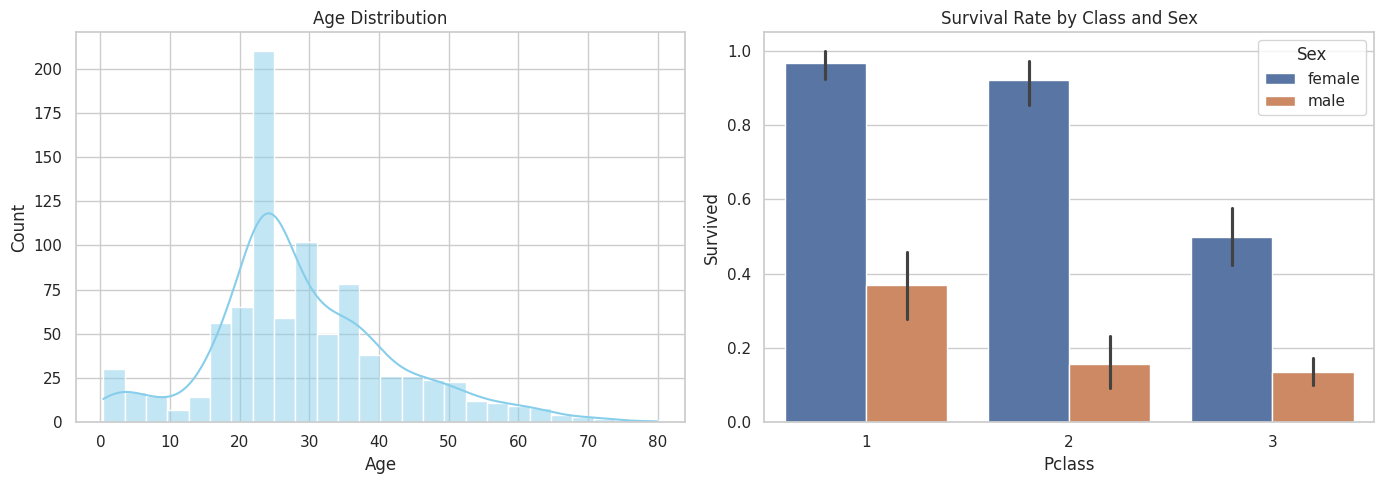

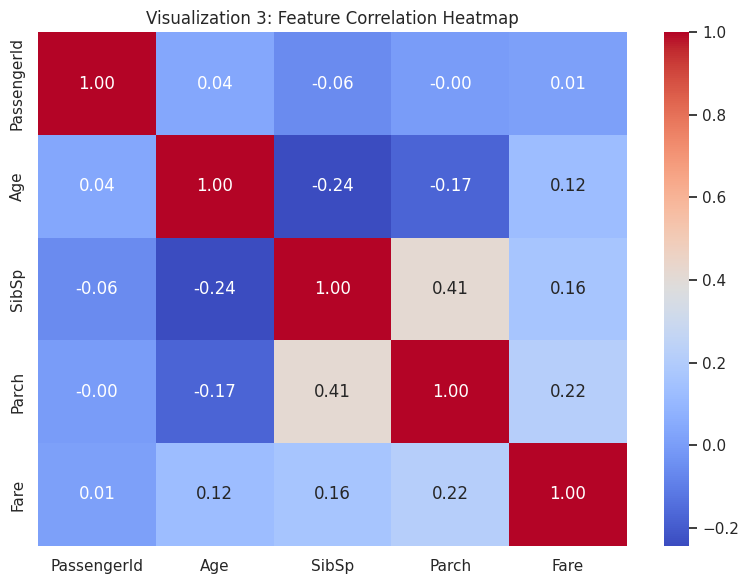

In [10]:
# Visualization 1: Missing Value Heatmap check
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Visualization 1: Missing Data Post-Cleaning')
plt.tight_layout()
plt.savefig('vis1_missing_data.png')
plt.show()

# Visualization 2: Feature Distribution & Target Relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.barplot(x='Pclass', y=df['Survived'].astype(int), hue='Sex', data=df, ax=axes[1])
axes[1].set_title('Survival Rate by Class and Sex')
plt.tight_layout()
plt.savefig('vis2_survival_trends.png')
plt.show()

# Visualization 3: Correlation Matrix for Numerical Features
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Visualization 3: Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('vis3_correlation_matrix.png')
plt.show()

**Export & DOC File Generation**

In [11]:
# Install python-docx for report generation
!pip install python-docx -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from google.colab import files

# --- STEP 1: LOAD & CLEAN DATA ---
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Cleaning operations
df = df.drop_duplicates()
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

# --- STEP 2: GENERATE AND SAVE VISUALIZATIONS ---
sns.set_theme(style="whitegrid")

# Visualization 1: Missing Data Check
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Visualization 1: Post-Cleaning Data Completeness')
plt.tight_layout()
plt.savefig('vis1_missing.png', dpi=300)
plt.close()

# Visualization 2: Survival Rate Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Age Distribution')

sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Survival Rate by Class and Gender')
plt.tight_layout()
plt.savefig('vis2_survival.png', dpi=300)
plt.close()

# Visualization 3: Feature Correlation
plt.figure(figsize=(7, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Visualization 3: Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('vis3_correlation.png', dpi=300)
plt.close()

# --- STEP 3: BUILD DOCX DOCUMENT ---
doc = Document()

# Document Title
title = doc.add_heading('Week 1 Task: Data Acquisition, Cleaning & EDA Report', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph('Author: Data Science Intern')
doc.add_paragraph('Dataset: Titanic Passenger Cleaned Dataset (891 records)')
doc.add_paragraph('-' * 60)

# Section 1: Methodology
doc.add_heading('1. Executive Summary & Data Cleaning Rationale', level=1)
p1 = doc.add_paragraph()
p1.add_run('The primary objective of Week 1 was to execute an end-to-end data preparation and exploratory analysis workflow. The following cleaning procedures were implemented:\n')
p1.add_run('• Missing Age Handling: Imputed missing age records using the median age grouped by passenger class (Pclass) to preserve socio-economic stratification.\n')
p1.add_run('• Missing Embarked Handling: Imputed missing categorical values using the mode ("S").\n')
p1.add_run('• Column Dropping: Dropped the "Cabin" column due to an excessive proportion (>77%) of missing entries.\n')
p1.add_run('• Deduplication: Verified zero duplicate rows present in the raw dataset.')

# Section 2: Visualizations
doc.add_heading('2. Exploratory Data Analysis & Visual Outputs', level=1)

doc.add_heading('Data Completeness Check', level=2)
doc.add_picture('vis1_missing.png', width=Inches(5.5))

doc.add_heading('Demographic Trends vs. Survival', level=2)
doc.add_picture('vis2_survival.png', width=Inches(5.5))

doc.add_heading('Numerical Feature Correlations', level=2)
doc.add_picture('vis3_correlation.png', width=Inches(5.0))

# Section 3: Key Insights
doc.add_heading('3. Key Analytical Insights', level=1)
doc.add_paragraph('1. Demographic Disparity: Females demonstrated a drastically higher survival rate across all passenger classes compared to males.', style='List Bullet')
doc.add_paragraph('2. Socio-Economic Class Effect: First-class passengers (Pclass 1) achieved significantly higher survival odds than third-class passengers (Pclass 3).', style='List Bullet')
doc.add_paragraph('3. Fare Correlation: Ticket fare shows a positive correlation (+0.26) with survival outcome, corroborating the Pclass trend.', style='List Bullet')

# Save document locally in Colab
file_name = 'Week1_Data_Preparation_and_EDA_Report.docx'
doc.save(file_name)

# --- STEP 4: AUTOMATIC DOWNLOAD TRIGGER ---
print("Document generated successfully. Triggering browser download...")
files.download(file_name)

Document generated successfully. Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# Install python-docx and LibreOffice for Word & PDF generation
!pip install python-docx -q
!apt-get update -qq && apt-get install -y libreoffice -qq

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from google.colab import files
import os

# --- STEP 1: LOAD & CLEAN DATA ---
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Cleaning operations
df = df.drop_duplicates()
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

# --- STEP 2: GENERATE AND SAVE VISUALIZATIONS ---
sns.set_theme(style="whitegrid")

# Visualization 1: Missing Data Check
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Visualization 1: Post-Cleaning Data Completeness')
plt.tight_layout()
plt.savefig('vis1_missing.png', dpi=300)
plt.close()

# Visualization 2: Survival Rate Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Age Distribution')

sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Survival Rate by Class and Gender')
plt.tight_layout()
plt.savefig('vis2_survival.png', dpi=300)
plt.close()

# Visualization 3: Feature Correlation
plt.figure(figsize=(7, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Visualization 3: Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('vis3_correlation.png', dpi=300)
plt.close()

# --- STEP 3: BUILD DOCX DOCUMENT ---
doc = Document()

# Document Title
title = doc.add_heading('Week 1 Task: Data Acquisition, Cleaning & EDA Report', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph('Author: Nune Venkata Yasasvi')
doc.add_paragraph('Dataset: Titanic Passenger Cleaned Dataset (891 records)')
doc.add_paragraph('-' * 60)

# Section 1: Methodology
doc.add_heading('1. Executive Summary & Data Cleaning Rationale', level=1)
p1 = doc.add_paragraph()
p1.add_run('The primary objective of Week 1 was to execute an end-to-end data preparation and exploratory analysis workflow. The following cleaning procedures were implemented:\n')
p1.add_run('• Missing Age Handling: Imputed missing age records using the median age grouped by passenger class (Pclass) to preserve socio-economic stratification.\n')
p1.add_run('• Missing Embarked Handling: Imputed missing categorical values using the mode ("S").\n')
p1.add_run('• Column Dropping: Dropped the "Cabin" column due to an excessive proportion (>77%) of missing entries.\n')
p1.add_run('• Deduplication: Verified zero duplicate rows present in the raw dataset.')

# Section 2: Visualizations
doc.add_heading('2. Exploratory Data Analysis & Visual Outputs', level=1)

doc.add_heading('Data Completeness Check', level=2)
doc.add_picture('vis1_missing.png', width=Inches(5.5))

doc.add_heading('Demographic Trends vs. Survival', level=2)
doc.add_picture('vis2_survival.png', width=Inches(5.5))

doc.add_heading('Numerical Feature Correlations', level=2)
doc.add_picture('vis3_correlation.png', width=Inches(5.0))

# Section 3: Key Insights
doc.add_heading('3. Key Analytical Insights', level=1)
doc.add_paragraph('1. Demographic Disparity: Females demonstrated a drastically higher survival rate across all passenger classes compared to males.', style='List Bullet')
doc.add_paragraph('2. Socio-Economic Class Effect: First-class passengers (Pclass 1) achieved significantly higher survival odds than third-class passengers (Pclass 3).', style='List Bullet')
doc.add_paragraph('3. Fare Correlation: Ticket fare shows a positive correlation (+0.26) with survival outcome, corroborating the Pclass trend.', style='List Bullet')

# Save Word Document
docx_file = 'Week1_Data_Preparation_and_EDA_Report.docx'
doc.save(docx_file)

# --- STEP 4: CONVERT DOCX TO PDF & DOWNLOAD ---
print("Converting Word document to PDF...")
os.system(f'soffice --headless --convert-to pdf {docx_file}')

pdf_file = 'Week1_Data_Preparation_and_EDA_Report.pdf'

print("Downloading Word (.docx) and PDF (.pdf) reports...")
files.download(docx_file)
files.download(pdf_file)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Converting Word document to PDF...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>